# 09 — Model 2: Prophet Time Series Forecast (Multivariate)
**Target:** Prediksi total views channel per hari (30 hari ke depan)  
**Peningkatan:** Menambahkan covariates (exogenous regressors) harian: `ctr_daily` & `engagement_daily` dengan peramalan/imputasi masa depan berbasis rolling baseline.  
**Algoritma:** Facebook Prophet + train/test split (80/20 kronologis)  
**Output:** `backend/models/model2_prophet_timeseries.pkl`, `data/processed/model_output_forecast.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os, warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
print("Libraries loaded ✓")

Libraries loaded ✓


In [2]:
# ── 1. LOAD & AGREGASI COVARIATES HARIAN ──────────────────────────────────────
df_features = pd.read_csv('../../data/processed/features_merged.csv')
df_clean = pd.read_csv('../../data/cleaned/abis_cleaning.csv')[['video_id', 'tanggal_upload']]
df_clean = df_clean.drop_duplicates(subset=['video_id'], keep='first')

df = pd.merge(df_features, df_clean, on='video_id', how='left')
df['publish_date'] = pd.to_datetime(df['tanggal_upload'], errors='coerce')

# Agregasi harian: views (sum), CTR & engagement (weighted mean by views)
def weighted_avg(group, val_col):
    d = group[val_col]
    w = group['views']
    if w.sum() == 0: return d.mean()
    return np.average(d, weights=w)

df_daily = df.groupby('publish_date').apply(lambda g: pd.Series({
    'y': g['views'].sum(),
    'ctr_daily': weighted_avg(g, 'ctr_normalized'),
    'engagement_daily': weighted_avg(g, 'engagement_score')
})).reset_index()

df_daily.columns = ['ds', 'y', 'ctr_daily', 'engagement_daily']
df_daily = df_daily.sort_values('ds').reset_index(drop=True)
df_daily = df_daily[df_daily['y'] > 0].reset_index(drop=True)

print(f"Total hari: {len(df_daily)}")
print(df_daily.tail(5))

Total hari: 487
            ds        y  ctr_daily  engagement_daily
482 2026-03-28  12127.0   0.165774          0.127070
483 2026-03-29  24687.0   0.182485          0.141641
484 2026-03-30  22556.0   0.190548          0.128122
485 2026-03-31  34265.0   0.173523          0.121390
486 2026-04-01  17245.0   0.158785          0.120291


In [3]:
# ── 2. TRAIN/TEST SPLIT KRONOLOGIS 80/20 ─────────────────────────────────────
split_idx  = int(len(df_daily) * 0.80)
train_df   = df_daily.iloc[:split_idx].copy()
test_df    = df_daily.iloc[split_idx:].copy()

print(f"Train: {len(train_df)} hari | Test: {len(test_df)} hari")

Train: 389 hari | Test: 98 hari


In [4]:
# ── 3. FIT MULTIVARIATE PROPHET ──────────────────────────────────────────────
model = Prophet(
    yearly_seasonality  = True,
    weekly_seasonality  = True,
    daily_seasonality   = False,
    changepoint_prior_scale = 0.05,
    seasonality_prior_scale = 10,
    interval_width      = 0.90,
    uncertainty_samples = 500,
    seasonality_mode    = 'multiplicative',
)

# Tambahkan exogenous regressors
model.add_regressor('ctr_daily')
model.add_regressor('engagement_daily')

# Tambah seasonality bulanan
model.add_seasonality(name='monthly', period=30.5, fourier_order=5)

model.fit(train_df)
print("Multivariate Prophet fitted ✓")

15:43:41 - cmdstanpy - INFO - Chain [1] start processing
15:43:41 - cmdstanpy - INFO - Chain [1] done processing


Multivariate Prophet fitted ✓


In [5]:
# ── 4. PREDIKSI DI TEST SET ──────────────────────────────────────────────────
# Test set sudah memiliki covariates aktual (tidak perlu imputasi untuk fase testing)
forecast_test = model.predict(test_df[['ds', 'ctr_daily', 'engagement_daily']])

# Merge dengan aktual
eval_df = test_df[['ds','y']].merge(forecast_test[['ds','yhat','yhat_lower','yhat_upper']], on='ds')
eval_df['yhat'] = eval_df['yhat'].clip(lower=0)

def mape(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100

rmse = np.sqrt(mean_squared_error(eval_df['y'], eval_df['yhat']))
mae  = mean_absolute_error(eval_df['y'], eval_df['yhat'])
mape_val = mape(eval_df['y'].values, eval_df['yhat'].values)
r2   = 1 - np.sum((eval_df['y'] - eval_df['yhat'])**2) / np.sum((eval_df['y'] - eval_df['y'].mean())**2)

print("=== EVALUASI TEST SET (MULTIVARIATE) ===")
print(f"RMSE : {rmse:,.0f} views")
print(f"MAPE : {mape_val:.2f}%")
print(f"R²   : {r2:.4f}")

=== EVALUASI TEST SET (MULTIVARIATE) ===
RMSE : 91,239 views
MAPE : 227.75%
R²   : -1.9088


In [6]:
# ── 5. FORECAST 30 HARI KE DEPAN (DENGAN ROLLING COVARIATES PROPAGATION) ─────
# Bikin dataframe masa depan
future_dates = pd.date_range(start=df_daily['ds'].max() + pd.Timedelta(days=1), periods=30)
future_30 = pd.DataFrame({'ds': future_dates})

# Imputasi covariates masa depan menggunakan rata-rata rolling 30 hari terakhir
last_ctr = df_daily['ctr_daily'].tail(30).mean()
last_eng = df_daily['engagement_daily'].tail(30).mean()

future_30['ctr_daily'] = last_ctr
future_30['engagement_daily'] = last_eng

# Gabung dengan data historis untuk full visualization
full_history = df_daily[['ds', 'ctr_daily', 'engagement_daily']].copy()
future_full = pd.concat([full_history, future_30], ignore_index=True)

forecast_all = model.predict(future_full)
forecast_export = forecast_all[['ds','yhat','yhat_lower','yhat_upper']].tail(30).copy()

forecast_export['yhat'] = forecast_export['yhat'].clip(lower=0).astype(int)
forecast_export['yhat_lower'] = forecast_export['yhat_lower'].clip(lower=0).astype(int)
forecast_export['yhat_upper'] = forecast_export['yhat_upper'].clip(lower=0).astype(int)

print("Forecast 30 hari ke depan sukses dihitung ✓")

Forecast 30 hari ke depan sukses dihitung ✓


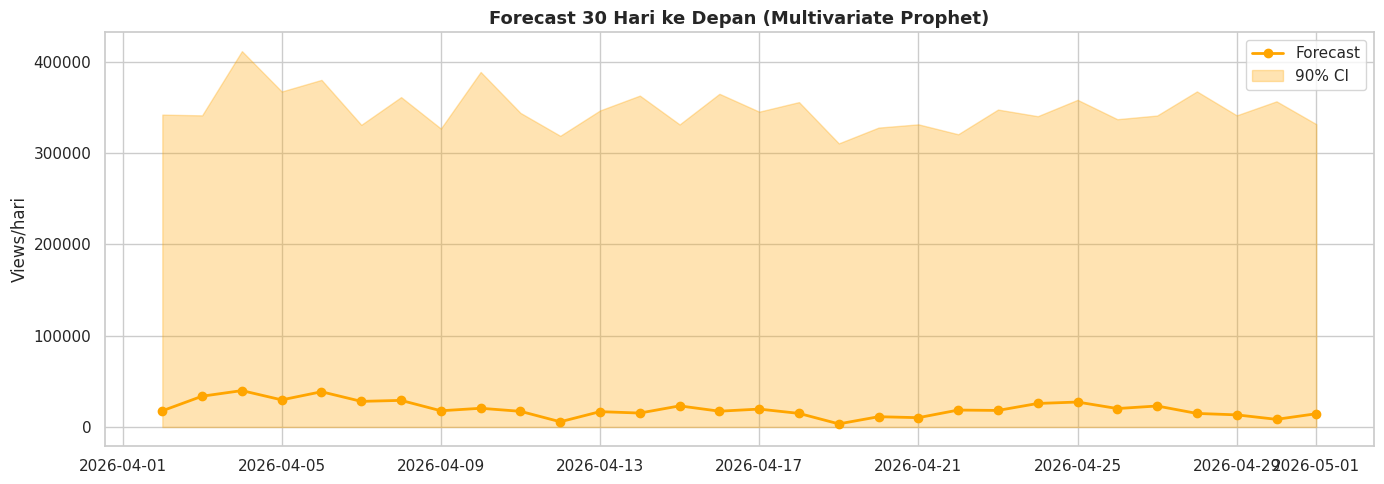

In [7]:
# ── 6. VISUALISASI FORECAST + CONFIDENCE INTERVAL ───────────────────────────
plt.figure(figsize=(14, 5))
plt.plot(forecast_export['ds'], forecast_export['yhat'], color='orange', linewidth=2, marker='o', label='Forecast')
plt.fill_between(forecast_export['ds'], forecast_export['yhat_lower'], forecast_export['yhat_upper'],
                 alpha=0.3, color='orange', label='90% CI')
plt.title('Forecast 30 Hari ke Depan (Multivariate Prophet)', fontsize=13, fontweight='bold')
plt.ylabel('Views/hari'); plt.legend(); plt.tight_layout()
plt.show()

In [8]:
# ── 7. SIMPAN MODEL & ARTIFACTS ──────────────────────────────────────────────
os.makedirs('../../backend/models', exist_ok=True)
joblib.dump(model, '../../backend/models/model2_prophet_timeseries.pkl')

forecast_export.to_csv('../../data/processed/model_output_forecast.csv', index=False)
print("Saved Prophet multivariate artifacts ✓")

Saved Prophet multivariate artifacts ✓
